# 미추홀구 실데이터 기초진단

샘플 자료를 사용하지 않는 후속 분석. `collect_real_data.py`로 저장한 완전 수집 스냅샷만 읽습니다.

**탐색적 결과**: 신기시장은 시장 API 대표점, 주안역·인하대후문은 해당 버스정류장의 평균좌표를 임시 중심으로 사용합니다. 법정 상권 경계나 보행권이 아니며, 정책 대상 범위는 지도 검토 후 확정해야 합니다. 구 밖 점포는 제외합니다.

기준월이 다른 교통자료는 접근성 참고자료로만 사용합니다. 동별 인구는 2026년 6월·8월 파일을 사용합니다. 실제 소비자료가 없으므로 소비전환·지원순위를 산출하지 않습니다.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import matplotlib.font_manager as fm

ROOT = Path.cwd()
if not (ROOT / 'data/raw').exists():
    ROOT = ROOT / 'Commercial district analysis'
OUT = ROOT / 'outputs'
OUT.mkdir(exist_ok=True)
for font in ['AppleGothic', 'Malgun Gothic', 'NanumGothic']:
    if any(f.name == font for f in fm.fontManager.ttflist):
        plt.rcParams['font.family'] = font
        break
plt.rcParams['axes.unicode_minus'] = False

def load(name):
    snapshot = json.loads((ROOT / 'data/raw' / (name + '.json')).read_text())
    assert snapshot['complete'] and len(snapshot['rows']) == snapshot['total']
    return snapshot, pd.DataFrame(snapshot['rows'])

store_meta, stores = load('district_stores')
market_meta, markets = load('market')
bus_meta, bus = load('bus_stop')
location_meta, locations = load('bus_location_incheon')
assert stores['bizesId'].notna().all() and stores['bizesId'].is_unique
assert stores['signguCd'].astype(str).eq('28177').all()
assert stores['indsMclsCd'].notna().all() and stores['indsMclsCd'].ne('').all()
for col in ['lat', 'lon']:
    stores[col] = pd.to_numeric(stores[col], errors='raise')
assert stores['lat'].between(37, 38).all() and stores['lon'].between(126, 127).all()
print('미추홀구 전체 점포:', len(stores), '기준월:', store_meta['standard_month'])


미추홀구 전체 점포: 18885 기준월: 202606


## 1. 버스 좌표 결합과 검증

인천BIS만 사용하고 모바일단축번호 + 공백 제거한 정류장명으로 정확히 결합합니다. 이름 변경·번호 충돌은 추정 결합하지 않고 미매칭으로 내보냅니다. 동일 키에 좌표가 여러 개면 제외합니다. 따라서 매칭된 정류장 기준 접근성은 전체 접근성의 일부일 수 있습니다.


In [2]:
def normalize_id(series):
    return series.astype('string').str.strip().str.replace(r'\.0$', '', regex=True)

def normalize_name(series):
    return series.astype('string').str.replace(r'\s+', '', regex=True)

loc = locations[locations['관리도시명'].eq('인천BIS')].copy()
loc['stop_id'] = normalize_id(loc['모바일단축번호'])
loc['stop_name_key'] = normalize_name(loc['정류장명'])
loc['lat'] = pd.to_numeric(loc['위도'], errors='coerce')
loc['lon'] = pd.to_numeric(loc['경도'], errors='coerce')
keys = ['stop_id', 'stop_name_key']
loc = loc.dropna(subset=keys + ['lat', 'lon'])
loc = loc[loc['lat'].between(37,38) & loc['lon'].between(126,127)]
loc = loc.drop_duplicates(keys + ['lat', 'lon'])
ambiguous = loc.duplicated(keys, keep=False)
loc[ambiguous].to_csv(OUT / 'bus_ambiguous_locations.csv', index=False)
loc_unique = loc[~ambiguous].copy()
bus['stop_id'] = normalize_id(bus['정류장 번호'])
bus['stop_name_key'] = normalize_name(bus['정류장명'])
assert not bus.duplicated(keys).any(), '동일 번호·이름의 승하차 중복을 먼저 확인하세요.'
joined = bus.merge(loc_unique[keys + ['lat','lon']], on=keys, how='left', validate='one_to_one', indicator=True)
joined['daily_passengers'] = pd.to_numeric(joined['일평균 승하차인원수'], errors='raise')
assert joined['daily_passengers'].ge(0).all()
unmatched = joined[joined['_merge'].eq('left_only')]
unmatched.to_csv(OUT / 'bus_unmatched.csv', index=False)
matched = joined[joined['_merge'].eq('both')].copy()
matched.to_csv(OUT / 'bus_matched.csv', index=False)
print(f'좌표 매칭: {len(matched):,}/{len(bus):,} ({len(matched)/len(bus):.1%})')
print('모집단은 승하차 원본 전체이며 미추홀구 내부 매칭률을 뜻하지 않습니다.')
print('모호한 위치행:', int(ambiguous.sum()), '미매칭:', len(unmatched))


좌표 매칭: 6,521/6,760 (96.5%)
모집단은 승하차 원본 전체이며 미추홀구 내부 매칭률을 뜻하지 않습니다.
모호한 위치행: 2 미매칭: 239


## 2. 임시 중심 검증

주안역환승정류장 37503·37617, 인하대후문 37165·37166·37167의 평균좌표를 사용합니다. 역 건물·후문 자체의 확정 좌표가 아닌 **대중교통 진입점 대푯값**입니다. 신기시장은 재래시장 데이터의 대표점입니다.


In [3]:
old_centers = {'주안역세권': (37.4599,126.6767), '신기시장': (37.4522,126.6663), '인하대후문': (37.4497,126.6555)}

def distance_m(lat, lon, center):
    a, b = np.radians(np.asarray(lat, dtype=float)), np.radians(np.asarray(lon, dtype=float))
    c, d = np.radians(center)
    h = np.sin((a-c)/2)**2 + np.cos(a)*np.cos(c)*np.sin((b-d)/2)**2
    return 6371000 * 2 * np.arcsin(np.sqrt(np.clip(h,0,1)))

centers = {}
center_sources = {}
for zone, ids, name in [('주안역세권', ['37503','37617'], '주안역환승정류장'), ('인하대후문', ['37165','37166','37167'], '인하대후문')]:
    selected = loc_unique[loc_unique['stop_id'].isin(ids) & loc_unique['정류장명'].eq(name)]
    assert len(selected) == len(ids), f'{zone}: 기준 정류장 누락'
    centers[zone] = tuple(selected[['lat','lon']].mean())
    center_sources[zone] = '전국 버스정류장 위치정보: ' + ', '.join(ids) + ' 평균'
market = markets[markets['시장명'].eq('신기시장')]
assert len(market) == 1
centers['신기시장'] = (float(market.iloc[0]['위도']),float(market.iloc[0]['경도']))
center_sources['신기시장'] = '미추홀구 재래시장: 신기시장 대표점'
ZONES = list(old_centers)
centers = {z: centers[z] for z in ZONES}
center_table = pd.DataFrame([dict(zone=z, lat=centers[z][0], lon=centers[z][1], old_to_new_m=float(distance_m(*old_centers[z], centers[z])), source=center_sources[z], status='임시 중심·정책경계 미확정') for z in ZONES])
center_table.to_csv(OUT / 'zone_centers.csv', index=False)
display(center_table)


,zone,lat,lon,old_to_new_m,source,status
0,주안역세권,37.464348,126.680191,582.673104,"전국 버스정류장 위치정보: 37503, 37617 평균",임시 중심·정책경계 미확정
1,신기시장,37.446216,126.678645,1276.897086,미추홀구 재래시장: 신기시장 대표점,임시 중심·정책경계 미확정
2,인하대후문,37.451232,126.656451,189.866662,"전국 버스정류장 위치정보: 37165, 37166, 37167 평균",임시 중심·정책경계 미확정


## 3. 구 전체 기준 LQ·다양성·반경 민감도

300m·500m·1km 내 점포를 독립적으로 집계합니다. 반경이 겹치는 점포는 각 상권에 포함하고 중복수를 따로 보고합니다. 상권별 수를 합산해 전체 점포 수라고 해석하지 않습니다. 기준집단은 항상 미추홀구 전체 2026년 6월 점포입니다.

LQ는 특화 정도이며 과밀·사업성 판정이 아닙니다. 희소 업종의 과도한 LQ 해석을 피하도록 점포 5개 미만을 별도 표시합니다. 업종 분류는 중분류 **코드** 기준입니다.


In [4]:
district_counts = stores.groupby('indsMclsCd').size()
district_share = district_counts / district_counts.sum()
category_names = stores.drop_duplicates('indsMclsCd').set_index('indsMclsCd')['indsMclsNm']
distances = pd.DataFrame({z: distance_m(stores['lat'],stores['lon'],c) for z,c in centers.items()}, index=stores.index)
results, summaries, memberships = [], [], []
for radius in [300,500,1000]:
    membership = distances.le(radius)
    overlap = membership.sum(axis=1).gt(1)
    for zone in ZONES:
        subset = stores[membership[zone]]
        assert len(subset) > 0
        counts = subset.groupby('indsMclsCd').size().reindex(district_counts.index, fill_value=0)
        shares = counts / counts.sum()
        lq = shares / district_share
        entropy = -(shares[shares.gt(0)] * np.log(shares[shares.gt(0)])).sum()
        summaries.append(dict(zone=zone,radius_m=radius,store_count=len(subset),overlap_store_count=int((membership[zone]&overlap).sum()),entropy=entropy,normalized_entropy=entropy/np.log(len(district_counts))))
        table = pd.DataFrame({'category_code': counts.index, 'category_name':category_names.reindex(counts.index).values, 'store_count':counts.values, 'district_count':district_counts.values, 'store_share':shares.values, 'district_share':district_share.values, 'LQ':lq.values})
        table['zone'],table['radius_m'] = zone,radius
        table['small_count'] = table['store_count'] < 5
        results.append(table)
        memberships.append(subset.assign(zone=zone,radius_m=radius))
summary = pd.DataFrame(summaries)
lq_table = pd.concat(results,ignore_index=True)
summary.to_csv(OUT / 'zone_summary.csv',index=False)
lq_table.to_csv(OUT / 'zone_lq.csv',index=False)
pd.concat(memberships,ignore_index=True).to_csv(OUT / 'zone_stores.csv',index=False)
display(summary.round(3))
print('500m 내 점포 5개 이상 업종 중 LQ 상위 5개 (지원순위 아님)')
display(lq_table.query('radius_m == 500 and store_count >= 5').sort_values(['zone','LQ'],ascending=[True,False]).groupby('zone').head(5)[['zone','category_name','store_count','LQ']].round(2))


,zone,radius_m,store_count,overlap_store_count,entropy,normalized_entropy
0,주안역세권,300,1215,0,3.387,0.787
1,신기시장,300,604,0,3.066,0.712
2,인하대후문,300,459,0,2.903,0.675
3,주안역세권,500,2154,0,3.484,0.810
4,신기시장,500,1087,0,3.163,0.735
5,인하대후문,500,783,0,3.228,0.750
6,주안역세권,1000,4641,0,3.519,0.818
7,신기시장,1000,3011,0,3.435,0.798
8,인하대후문,1000,2750,0,3.529,0.820


500m 내 점포 5개 이상 업종 중 LQ 상위 5개 (지원순위 아님)


,zone,category_name,store_count,LQ
354,신기시장,의원,53,2.08
299,신기시장,식료품 소매,78,2.03
316,신기시장,중고 상품 소매,9,1.65
358,신기시장,유원지·오락,48,1.46
309,신기시장,의약·화장품 소매,35,1.41
392,인하대후문,기타 숙박,42,9.47
419,인하대후문,사무 지원,8,6.65
430,인하대후문,도서관·사적지,16,5.68
396,인하대후문,서양식,20,4.59
397,인하대후문,동남아시아,5,4.16


## 4. 지도 검토용 그림

점포 좌표·시장 대표점·이전 중심·수정 중심·500m 원을 같은 미터 근사 좌표계에 표시합니다. 배경 도로·철도와 정책 경계는 포함하지 않습니다. `zone_review.geojson`을 GIS 지도에 불러와 실제 보행권을 검토할 수 있습니다. 면적당 밀도는 구 경계와 보행권 확정 후 계산합니다.


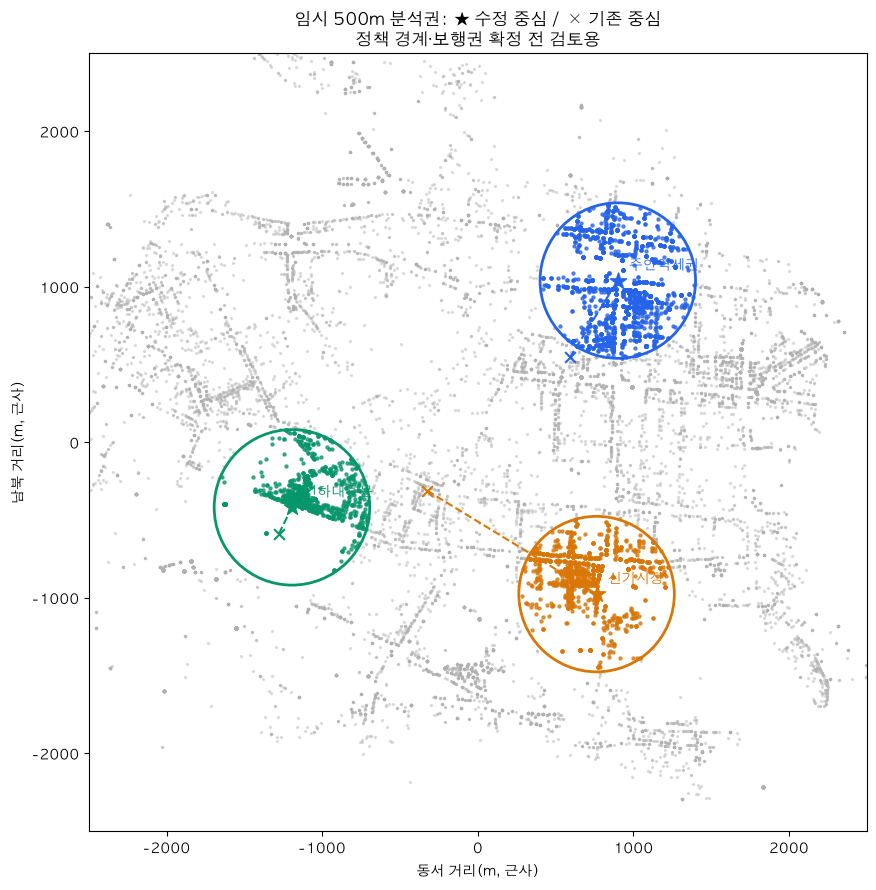

10044

In [5]:
origin = (37.455,126.67)
def xy(lat,lon):
    return ((np.asarray(lon,dtype=float)-origin[1])*np.pi/180*6371000*np.cos(np.radians(origin[0])), (np.asarray(lat,dtype=float)-origin[0])*np.pi/180*6371000)
fig, ax = plt.subplots(figsize=(10,9))
x,y = xy(stores['lat'],stores['lon'])
ax.scatter(x,y,s=2,c='#b0b0b0',alpha=.35,label='구 전체 점포')
colors = ['#2563eb','#d97706','#059669']
features=[]
for zone,color in zip(ZONES,colors):
    cx,cy = xy(*centers[zone]); ox,oy = xy(*old_centers[zone])
    subset=stores[distances[zone].le(500)]
    sx,sy=xy(subset['lat'],subset['lon'])
    ax.scatter(sx,sy,s=5,color=color,alpha=.65)
    ax.add_patch(Circle((cx,cy),500,fill=False,color=color,lw=2))
    ax.scatter([cx],[cy],marker='*',s=150,color=color)
    ax.scatter([ox],[oy],marker='x',s=60,color=color)
    ax.plot([ox,cx],[oy,cy],ls='--',color=color)
    ax.annotate(zone,(cx,cy),xytext=(8,8),textcoords='offset points',color=color)
    lat,lon=centers[zone]
    features.append(dict(type='Feature',properties=dict(zone=zone,kind='provisional_center',source=center_sources[zone]),geometry=dict(type='Point',coordinates=[lon,lat])))
    # ponytail: spherical circles; use walking-network polygons once policy boundaries are agreed.
    bearings=np.linspace(0,2*np.pi,73); angular=500/6371000
    a,b=np.radians([lat,lon])
    la=np.arcsin(np.sin(a)*np.cos(angular)+np.cos(a)*np.sin(angular)*np.cos(bearings))
    lo=b+np.arctan2(np.sin(bearings)*np.sin(angular)*np.cos(a),np.cos(angular)-np.sin(a)*np.sin(la))
    ring=np.column_stack([np.degrees(lo),np.degrees(la)]).tolist(); ring[-1]=ring[0]
    features.append(dict(type='Feature',properties=dict(zone=zone,kind='provisional_500m_circle'),geometry=dict(type='Polygon',coordinates=[ring])))
ax.set_aspect('equal');ax.set_xlim(-2500,2500);ax.set_ylim(-2500,2500)
ax.set_xlabel('동서 거리(m, 근사)');ax.set_ylabel('남북 거리(m, 근사)')
ax.set_title('임시 500m 분석권: ★ 수정 중심 / × 기존 중심\n정책 경계·보행권 확정 전 검토용')
fig.tight_layout();fig.savefig(OUT / 'zone_review.png',dpi=160);plt.show()
(OUT/'zone_review.geojson').write_text(json.dumps(dict(type='FeatureCollection',features=features),ensure_ascii=False),encoding='utf-8')


## 5. 버스 접근성 참고지표

좌표가 연결된 정류장의 일평균 승하차를 거리 감쇠해 합산합니다. β=0.0015/m는 기존 시연값을 유지한 가정이며, 직선거리 1km까지 계산합니다. 하차만 사용한 지표도 병기합니다. 승하차는 방문자 수나 소비전환율이 아닙니다. 철도 승하차는 포함하지 않습니다.

승하차와 위치자료의 기준시점 차이·미매칭이 있어 상권 지원순위에 사용하지 않습니다. 일평균 하차는 원본 일평균 승하차에 총 하차 비중을 적용한 값입니다.


In [6]:
access_rows=[]
board=pd.to_numeric(matched['승차인원수'],errors='raise')
alight=pd.to_numeric(matched['하차인원수'],errors='raise')
assert board.ge(0).all() and alight.ge(0).all()
matched['daily_alighting'] = matched['daily_passengers'] * alight.div((board+alight).replace(0,np.nan)).fillna(0)
for zone,center in centers.items():
    d=distance_m(matched['lat'],matched['lon'],center)
    inside=d<=1000
    for beta in [.001,.0015,.002]:
        weights=np.exp(-beta*d[inside])
        access_rows.append(dict(zone=zone,beta_per_m=beta,matched_stops=int(inside.sum()),weighted_daily_board_alight=float((matched.loc[inside,'daily_passengers']*weights).sum()),weighted_daily_alight=float((matched.loc[inside,'daily_alighting']*weights).sum())))
accessibility=pd.DataFrame(access_rows)
accessibility.to_csv(OUT/'bus_accessibility_provisional.csv',index=False)
display(accessibility.round(2))


,zone,beta_per_m,matched_stops,weighted_daily_board_alight,weighted_daily_alight
0,주안역세권,0.0,64,41335.47,20138.94
1,주안역세권,0.0,64,35018.89,16942.09
2,주안역세권,0.0,64,30391.68,14594.42
3,신기시장,0.0,85,27281.06,13459.84
4,신기시장,0.0,85,21357.04,10520.31
5,신기시장,0.0,85,17005.66,8362.53
6,인하대후문,0.0,58,26830.34,13211.19
7,인하대후문,0.0,58,20192.06,9937.52
8,인하대후문,0.0,58,15530.44,7643.58


## 6. 실행 검증과 다음 데이터

필요 데이터와 공식 신청 URL은 `docs/실데이터_진행현황_API안내.md`를 참조합니다. 다음 단계는 지도에서 정책 경계를 확정하고, 동별 연령인구와 실제 소비자료의 공간 단위를 맞추는 것입니다.


In [7]:
# 최소 회귀검증: 거리·LQ 기준집단·반경 포함관계·조인 무증식
assert float(distance_m(37.45,126.67,(37.45,126.67))) == 0
assert 110000 < float(distance_m(37,126,(38,126))) < 112000
assert np.allclose(district_share / district_share,1)
assert len(joined) == len(bus)
assert not matched.duplicated(keys).any()
for zone in ZONES:
    counts=summary[summary.zone.eq(zone)].sort_values('radius_m')['store_count'].to_numpy()
    assert np.all(np.diff(counts)>=0)
for _,table in lq_table.groupby(['zone','radius_m']):
    assert np.isclose((table['LQ']*table['district_share']).sum(),1)
assert normalize_id(pd.Series(['037165','37165.0',None])).tolist()[:2] == ['037165','37165']
print('PASS: 완전 수집·중복·좌표·LQ·반경·버스 조인 검증')


PASS: 완전 수집·중복·좌표·LQ·반경·버스 조인 검증


## 7. 동별 1세 인구 및 상권 관련 행정동

2026년 8월을 최신 현황, 6월을 점포·승하차와 동시점 비교 기준으로 사용합니다. 원본은 미추홀구 합계와 21개 행정동, 남녀 및 합계, 0~99세·100세 이상입니다. 100은 정확히 100세가 아니라 상단 개방구간입니다.

20~39세는 분석용 연령구간이며 정책상 청년 정의가 아닙니다. 상권의 500m 내 점포가 속한 행정동을 연결합니다. **행정동 전체 인구는 500m 상권 거주인구가 아니며, 점포비중으로 인구를 배분하지 않습니다.** 관련 동 목록은 점포 소재지 기반이므로 주거지만 포함하는 동을 빠뜨릴 수 있습니다.


In [8]:
import re

def read_population(path, month):
    try:
        frame = pd.read_csv(path, encoding='utf-8-sig', dtype=str)
    except UnicodeDecodeError:
        frame = pd.read_csv(path, encoding='cp949', dtype=str)
    codes = frame['행정구역'].str.extract(r'\((\d{10})\)')[0]
    assert codes.notna().all() and codes.is_unique
    assert codes.str.startswith('28177').all()
    assert len(codes) == 22 and '2817700000' in set(codes)
    prefix = f'{month[:4]}년{month[4:]}월'
    age_labels = [f'{age}세' for age in range(100)] + ['100세 이상']
    records = []
    totals = {}
    for sex in ['계','남','여']:
        columns = [f'{prefix}_{sex}_{label}' for label in age_labels]
        values = frame[columns].apply(lambda col: pd.to_numeric(col.str.replace(',', '', regex=False), errors='raise'))
        total = pd.to_numeric(frame[f'{prefix}_{sex}_총인구수'].str.replace(',', '', regex=False), errors='raise')
        interval = pd.to_numeric(frame[f'{prefix}_{sex}_연령구간인구수'].str.replace(',', '', regex=False), errors='raise')
        assert values.notna().all().all() and (values >= 0).all().all()
        assert (values % 1 == 0).all().all()
        assert values.sum(axis=1).eq(total).all() and interval.eq(total).all()
        values.index = codes
        assert values.drop(index='2817700000').sum().equals(values.loc['2817700000'])
        totals[sex] = values.to_numpy()
        for row, code in enumerate(codes):
            name = re.sub(r'\s*\(\d{10}\)', '', frame.iloc[row]['행정구역']).strip()
            for age in range(101):
                records.append(dict(month=month, dong_code=code, region_name=name, sex=sex,
                                    age_lower=age, age_label=age_labels[age], population=int(values.iloc[row,age])))
    assert np.array_equal(totals['남'] + totals['여'], totals['계'])
    return pd.DataFrame(records)

populations=[]
for month in ['202606','202608']:
    paths=list((ROOT/'data').glob(f'{month}_{month}_*.csv'))
    assert len(paths)==1, f'{month}: 인구 원본 파일은 하나여야 합니다.'
    populations.append(read_population(paths[0],month))
population=pd.concat(populations,ignore_index=True)
assert not population.duplicated(['month','dong_code','sex','age_lower']).any()
population.to_csv(OUT/'population_age_1year.csv',index=False)

rows=[]
for (month,dong),g in population[population.sex.eq('계')].groupby(['month','dong_code']):
    total=g.population.sum()
    row=dict(month=month,dong_code=dong,region_name=g.region_name.iloc[0],total_population=int(total))
    for name,lo,hi in [('age_0_14',0,14),('age_20_39',20,39),('age_65_plus',65,100)]:
        count=int(g.loc[g.age_lower.between(lo,hi),'population'].sum())
        row[name]=count
        row[name+'_pct']=count/total*100 if total else np.nan
    rows.append(row)
pop_summary=pd.DataFrame(rows)
pop_summary.to_csv(OUT/'population_dong_summary.csv',index=False)
base=pop_summary[pop_summary.month.eq('202606')].set_index('dong_code')
latest=pop_summary[pop_summary.month.eq('202608')].set_index('dong_code').copy()
assert set(base.index)==set(latest.index)
latest['change_from_june']=latest.total_population-base.total_population
latest['change_from_june_pct']=latest.change_from_june/base.total_population*100
latest.reset_index().to_csv(OUT/'population_change_jun_aug.csv',index=False)
print('검증 통과: 2개 월 × 22지역 × 3성별 × 101연령구간 =',len(population),'행')
display(latest.loc[['2817700000']].round(2))

# API의 8자리 행정동 코드를 원본 인구의 10자리로 정규화하고 명칭도 대조합니다.
zone_dongs=[]
for zone in ZONES:
    subset=stores[distances[zone].le(500)].copy()
    assert subset.adongCd.astype(str).str.fullmatch(r'\d{8}').all()
    subset['dong_code']=subset.adongCd.astype(str)+'00'
    grouped=subset.groupby(['dong_code','adongNm']).size().rename('zone_store_count').reset_index()
    grouped['zone']=zone
    grouped['zone_store_share_pct']=grouped.zone_store_count/len(subset)*100
    zone_dongs.append(grouped)
links=pd.concat(zone_dongs,ignore_index=True)
assert set(links.dong_code)<=set(latest.index)-{'2817700000'}
context=links.merge(latest.reset_index(),on='dong_code',how='left',validate='many_to_one')
assert context.apply(lambda row: row.region_name.split()[-1]==row.adongNm,axis=1).all()
context['population_scope']='행정동 전체 (상권 거주인구 아님)'
context.to_csv(OUT/'zone_dong_population_context.csv',index=False)
display(context[['zone','adongNm','zone_store_count','zone_store_share_pct','total_population','age_20_39_pct','age_65_plus_pct']].round(2))


검증 통과: 2개 월 × 22지역 × 3성별 × 101연령구간 = 13332 행


,month,region_name,total_population,age_0_14,age_0_14_pct,age_20_39,age_20_39_pct,age_65_plus,age_65_plus_pct,change_from_june,change_from_june_pct
dong_code,,,,,,,,,,,
2817700000,202608,인천광역시 미추홀구,419123,38260,9.13,107077,25.55,93218,22.24,912,0.22


,zone,adongNm,zone_store_count,zone_store_share_pct,total_population,age_20_39_pct,age_65_plus_pct
0,주안역세권,도화1동,19,0.88,20271,24.58,24.00
1,주안역세권,주안1동,1566,72.70,19903,35.70,16.12
2,주안역세권,주안5동,569,26.42,18917,26.43,24.96
3,신기시장,학익2동,24,2.21,17534,22.41,26.92
4,신기시장,주안3동,66,6.07,12045,24.72,24.25
5,신기시장,주안7동,787,72.40,12020,20.00,30.87
6,신기시장,주안8동,210,19.32,18365,21.13,27.07
7,인하대후문,용현1.4동,743,94.89,17171,36.85,25.93
8,인하대후문,용현3동,38,4.85,6519,23.42,34.18
9,인하대후문,학익1동,2,0.26,41456,25.64,16.53
